# Lottery Addiction: You Will Never Win... *(Probably)*

## Aim

The goal of this project is to define functions to calculate probabilities and demonstrate just how lucky you need to be to win a standard 6/49 lottery. To give this project some context, we are developing a hypothetical app aiming to treat lottery addiction. The idea is to help addicts by enabling them to grasp just how unlikely it is to make a profit from the lottery.

For the first version of the app, the focus will be on the standard 6/49 lottery: players choose 6 different numbers between 1-49 inclusive and aim to match all 6 to win the jackpot (a fixed prize of CA$5 million which rolls-over to the next week's draw if not won the previous week). 

To do this, functions must be created to answer the following questions:

* What is the probability of winning the jackpot with a single ticket?
* What is the probability of winning the jackpot playing multiple tickets? (5, 10, 100, ...)
* What is the probability of having a ticket with at least three (or four, or five) winning numbers?

The project will also utilise a publically available [dataset](https://www.kaggle.com/datasets/datascienceai/lottery-dataset) on historical lottery data in Canada. This will be used to determine if a given set of six numbers would have ever won over the time period of the dataset.

## Defining Core Logic to Calculate Probabilities

Below, we define a number of functions to handle the core probability logic:

* `factorial()` - calculates the factorial of a number.
* `combinations()` - calculates the total number of possible combinations when selecting r items from n items.
* `binomial()` - calculates binomial distribution probabilities to find the likelihood of getting exactly r successes from n trials with a success probability of p.

In [1]:
def factorial(num):
  """Calculates the factorial of a number. The input must be a natural number."""
  result = 1
  
  if (num < 0) or (type(num) != int):    # check for valid input
    return "Error: Input must be a positive integer."
  
  for i in range(1, num+1):
    result *= i    
  return result

Note, the above function has a time dependency of O(n), meaning the function runtime scales linearly with the input size (i.e., performance will suffer with large num inputs). This could be optimized by instead importing the `math.factorial() function` to eliminate the Python overhead. The `math.factorial() function` is implemented C programming language which is far faster. 

For the sake of building the function from first principles, we will continue on with the Python implemented function.

In [2]:
factorial(6)  # Example usage, expects output of 720

720

In [3]:
factorial(-2)  # Example usage, expects error message

'Error: Input must be a positive integer.'

In [4]:
factorial(0.2)  # Example usage, expects error message

'Error: Input must be a positive integer.'

In [5]:
def combinations(n, r):
  """Calculates the number of possible combinations when selecting r items from n items. Both n and r must be natural numbers with n >= r."""
  
  try:
    result = factorial(n) // (factorial(r) * factorial(n - r))     # n! / (r! * (n - r)!)
    return result
  
  except (TypeError, MemoryError, OverflowError):
    return "Error: Invalid input for combinations calculation. Ensure n and r are natural numbers with n >= r."

Since this function calls the Python defined factorial function, it too has an O(n) time dependency and will have vast runtimes as n becomes large. For the sake of developing the project from first principles, we are foregoing the optimization of the factorial function however.

In [6]:
combinations(12, 6)  # Example usage, expects output of 924

924

In [7]:
combinations(6, 9)  # Example usage, expects error message

'Error: Invalid input for combinations calculation. Ensure n and r are natural numbers with n >= r.'

In [8]:
combinations(30, -1)  # Example usage, expects error message

'Error: Invalid input for combinations calculation. Ensure n and r are natural numbers with n >= r.'

Below, a further function is defined where a user can input a list of their chosen lottery numbers. The output informs the user of their chances of matching all six numbers and winning the jackpot.

In [9]:
def play_one_ticket(user_numbers: list):
  
  if len(user_numbers) == 6:
    outcomes = combinations(49, 6)  # total possible combinations in a 6/49 lottery
    p_win = 1 / outcomes              # probability of winning with one ticket
    p_win_percent = p_win * 100   
    
    return f"Your chances of winning the lottery with numbers {user_numbers} are 1 in {outcomes:,}, or {p_win_percent:.8f}%"
  
  else:
    return "Error: You must select exactly 6 numbers."                  

In [10]:
play_one_ticket([3, 15, 27, 34, 42, 49]) # test case 1, expects valid output

'Your chances of winning the lottery with numbers [3, 15, 27, 34, 42, 49] are 1 in 13,983,816, or 0.00000715%'

In [11]:
play_one_ticket([5, 12, 19, 23, 24, 30])  # test case 2, expects valid output

'Your chances of winning the lottery with numbers [5, 12, 19, 23, 24, 30] are 1 in 13,983,816, or 0.00000715%'

In [12]:
play_one_ticket([5, 12, 19])  # test case 3, expects error message

'Error: You must select exactly 6 numbers.'

Above, we see the chance of winning the jackpot playing one ticket. It is exceedingly unlikely, the odds of winning are **1 in 13,983,816**.

---
To delve deeper into the subject, we can move to ask questions such as **"What are the chances of winning if you play multiple (5, 10, 20, ...) tickets?"**

To answer this, we employ the Binomial Distribution to model the probabilities associated with the entire sample space (every possible combination of 6 numbers in the set {1-49}):

## Binomial Distribution Function

A random variable (often denoted as X or Y) is a variable whose value depends on the outcome of a random event. In this context, a random variable can be defined to be the number of jackpots achieved from n tickets played.

To fully describe the probability of all outcomes in the sample space, a probability distribution can be used. We are looking to find the probability of getting 1 success from n independent trials (n tickets played). The probability of success is fixed at p (calculated above).

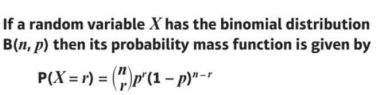

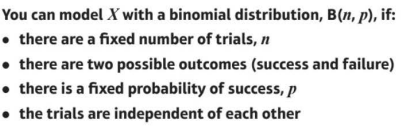

Since the scenario fits the criteria for the Binomial Distribution as listed in the figure above, modelling the probability with this distribution is sensible.

We therefore define the `binomial()` function below to implement the Binomial Distribution formula for the purpose of calculating probabilities to answer questions such as "What is the probability of winning the jackpot playing 5 (or 10, or 20) tickets?"

In [13]:
p = 1 / combinations(49, 6)  # probability of winning with one ticket

from math import log, exp

def binomial(n, p=p, r=1):
  """Calculates the binomial probability of getting exactly r successes in n independent Bernoulli trials with success probability p."""
  
  try:
    log_probability = log(combinations(n, r)) + r*log(p) + (n-r)*log(1-p)  # log of the probability: log(nCr * p^r * ((1-p)^(n-r))
    probability = exp(log_probability)  # exponentiate to get the actual probability
    percentage = probability * 100
    return f"The chance of hitting the jackpot with {n:,} lottery ticket(s) is 1 in {1/probability:,.0f} ({percentage:.8f}%)"
  
  except (TypeError, MemoryError):
    return "Error: Invalid input for binomial probability calculation. Ensure n and r are natural numbers with n >= r, and p is between 0 and 1."

The logic of the above function calculates the log of the probability. This is done for **numerical stability** to handle cases of extremely large values of n - i.e., as the number of tickets, n, becomes very large (n > 1,000,000), direct computation of (1-p)^(n-r) loses precision due to underflow.

We test the function below by passing a list of ticket values:

In [14]:
import datetime as dt
number_of_tickets = [1, 10, 50, 100, 1000, 5000, 10000, 100000, 141258, 200000, 300000]

current_time = dt.datetime.now()

for i in number_of_tickets:
  print(f"{binomial(i)} | Calculation time: {str((dt.datetime.now() - current_time))} |") # print formatted results alongside the time elapsed for each calculation
  print("---------------------------------------------------------------------------------------------------------------------------------")

The chance of hitting the jackpot with 1 lottery ticket(s) is 1 in 13,983,816 (0.00000715%) | Calculation time: 0:00:00 |
---------------------------------------------------------------------------------------------------------------------------------
The chance of hitting the jackpot with 10 lottery ticket(s) is 1 in 1,398,383 (0.00007151%) | Calculation time: 0:00:00 |
---------------------------------------------------------------------------------------------------------------------------------
The chance of hitting the jackpot with 50 lottery ticket(s) is 1 in 279,677 (0.00035755%) | Calculation time: 0:00:00 |
---------------------------------------------------------------------------------------------------------------------------------
The chance of hitting the jackpot with 100 lottery ticket(s) is 1 in 139,839 (0.00071511%) | Calculation time: 0:00:00 |
-----------------------------------------------------------------------------------------------------------------------------

Above, we calculate the chances of getting a single win playing 1, 10, 50, ... lottery tickets. As is apparent, the chances remain exceedingly small even in cases where a significant number of tickets are played.

Amazingly, even for just a 1% chance at winning the jackpot, you would need to purchase 141,258 tickets! As of Jan 2026, the price per ticket is CA$3.00. Purchasing enough tickets to give you a 1% chance of winning the jackpot would therefore cost CA$423,774.00 (equivalent to US$311,831.98 | GBP£226,280.48).

This is clearly beyond a reasonable cost to justify such a small likelihood of winning the jackpot.

>*A note on performance*
>
>With regards to the runtime performance, we see the runtime begins markedly increasing as the value of n (number of tickets) becomes larger and larger. This is due to the computational demand of calculating combinations with large n (since the logic requires large factorials to be calculated).

## Historical 649 Lotttery Data

Below, we import the publically available [649 Lotto Dataset](https://www.kaggle.com/datasets/datascienceai/lottery-dataset). This will be utilised to create a historical function that enables users to check to see if their numbers have ever been drawn over the 36 year period that this dataset covers.

In [15]:
import pandas as pd

canada_649_lottery_data = pd.read_csv("649-lottery-data.csv", parse_dates=["DRAW DATE"])

canada_649_lottery_data.head()

,PRODUCT,DRAW NUMBER,SEQUENCE NUMBER,DRAW DATE,NUMBER DRAWN 1,NUMBER DRAWN 2,NUMBER DRAWN 3,NUMBER DRAWN 4,NUMBER DRAWN 5,NUMBER DRAWN 6,BONUS NUMBER
0,649,1,0,1982-06-12,3,11,12,14,41,43,13
1,649,2,0,1982-06-19,8,33,36,37,39,41,9
2,649,3,0,1982-06-26,1,6,23,24,27,39,34
3,649,4,0,1982-07-03,3,9,10,13,20,43,34
4,649,5,0,1982-07-10,5,14,21,31,34,47,45


In [16]:
canada_649_lottery_data.shape

(3665, 11)

In [17]:
canada_649_lottery_data["DRAW DATE"].min(), canada_649_lottery_data["DRAW DATE"].max()

(Timestamp('1982-06-12 00:00:00'), Timestamp('2018-06-20 00:00:00'))

In [18]:
canada_649_lottery_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3665 entries, 0 to 3664
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   PRODUCT          3665 non-null   int64         
 1   DRAW NUMBER      3665 non-null   int64         
 2   SEQUENCE NUMBER  3665 non-null   int64         
 3   DRAW DATE        3665 non-null   datetime64[us]
 4   NUMBER DRAWN 1   3665 non-null   int64         
 5   NUMBER DRAWN 2   3665 non-null   int64         
 6   NUMBER DRAWN 3   3665 non-null   int64         
 7   NUMBER DRAWN 4   3665 non-null   int64         
 8   NUMBER DRAWN 5   3665 non-null   int64         
 9   NUMBER DRAWN 6   3665 non-null   int64         
 10  BONUS NUMBER     3665 non-null   int64         
dtypes: datetime64[us](1), int64(10)
memory usage: 315.1 KB


We see the dataset contains historical data on the 3,665 drawings dating from 1982 to 2018. The winning numbers for each drawing are present in the columns `NUMBER DRAWN 1` up to 6. 

Note, there is an additional `BONUS NUMBER` column. As per the 649 Lotto classic draw rules, this is not relevant to winning the fixed CA$5 million jackpot - this only comes into play for winning the second prize (between CA$100,000 to CA$500,000) where bettors must match five of the six winning numbers plus the bonus ball. For this reason, we do not need to consider the bonus ball for calculating probabilities associated with winning the jackpot.

In [19]:
def extract_numbers(row):
  winning_numbers = [row['NUMBER DRAWN 1'], row['NUMBER DRAWN 2'], row['NUMBER DRAWN 3'], row['NUMBER DRAWN 4'], row['NUMBER DRAWN 5'], row['NUMBER DRAWN 6']]
  return winning_numbers

The above function is defined to extract the winning numbers from the dataset as a list.

In [20]:
winning_numbers = canada_649_lottery_data.apply(extract_numbers, axis=1)
winning_numbers.head()

0    [3, 11, 12, 14, 41, 43]
1    [8, 33, 36, 37, 39, 41]
2     [1, 6, 23, 24, 27, 39]
3     [3, 9, 10, 13, 20, 43]
4    [5, 14, 21, 31, 34, 47]
dtype: object

In [21]:
def check_historical_occurrences(user_numbers: list, historical_winning_numbers=winning_numbers):
  """Checks how many times the user's selected numbers have occurred in the historical lottery data."""
  occurrence_count = 0
  
  if len(user_numbers) != 6:
    return "Error: You must select exactly 6 numbers."
  
  user_numbers = sorted(user_numbers)  # sort user numbers for comparison
  
  for historical_numbers in historical_winning_numbers:
    if sorted(historical_numbers) == user_numbers:
        occurrence_count += 1
        
  if occurrence_count == 0:
    print(f"""The numbers {user_numbers} have never occurred in the historical lottery data. This does NOT mean it is more likely to occur now or in the future. 
Your chances of winning the jackpot is still 1 in 13,983,816.""")
  
  else:
    print(f"""The numbers {user_numbers} have occurred {occurrence_count} time(s) in the historical lottery data. 
It does not matter how many times these numbers have occurred previously, your chances of winning the jackpot are still 1 in 13,983,816.""")


We then define the function above for users to check whether their numbers have ever occurred in the recorded 36 years of the dataset.

In [22]:
check_historical_occurrences([3, 15, 27, 34, 42]) # test case 1, expects error message 

'Error: You must select exactly 6 numbers.'

In [23]:
check_historical_occurrences([3, 15, 27, 34, 42, 49])  # test case 2, expect 0 occurrences

The numbers [3, 15, 27, 34, 42, 49] have never occurred in the historical lottery data. This does NOT mean it is more likely to occur now or in the future. 
Your chances of winning the jackpot is still 1 in 13,983,816.


In [24]:
check_historical_occurrences([5, 14, 21, 31, 34, 47])  # test case 3, expect 1 occurrence

The numbers [5, 14, 21, 31, 34, 47] have occurred 1 time(s) in the historical lottery data. 
It does not matter how many times these numbers have occurred previously, your chances of winning the jackpot are still 1 in 13,983,816.


## Chances of Matching Fewer Than Six Winning Numbers

Finally, we move to answer the question of how likely it is to match fewer than six winning numbers (and potentially still take home some winnings). To do this, the following function is defined which handles the core probability logic to return the probability of matching a given number of winning numbers.

In [25]:
def matching_numbers(number_of_matches):
  
  """Calculates the probability of matching a specific number of winning numbers in a 6/49 lottery."""
  
  if (number_of_matches < 0) or (number_of_matches > 6) or (type(number_of_matches) != int):
    return "Error: Number of matches must be an integer between 0 and 6."
  
  if number_of_matches == 6:              # jackpot case
    
    p_success = 1 / combinations(49, 6)
    p_success_percent = p_success * 100
    return p_success_percent
  
  else:                   # non-jackpot cases (0 to 5 matching numbers)
    
    total_combinations_of_n_winning_numbers = combinations(6, number_of_matches)  # the total number of combinations possible for the matched numbers
    remaining_combinations = combinations(43, 6 - number_of_matches)  # the total number of combinations for the remaining unmatched numbers
    successful_outcomes = total_combinations_of_n_winning_numbers * remaining_combinations # total successful outcomes for the given number of matches
    p_success = successful_outcomes / combinations(49, 6)
    p_success_percent = p_success * 100
    
    return p_success_percent

The function is implemented below, placing the results into a dataframe for cleaner presentation.

In [26]:
pd.options.display.float_format = '{:.8f}'.format # set pandas to display floats with 8 decimal places

match_probabilities = pd.DataFrame(columns=["Matches", "Probability (%)"])
match_probabilities["Matches"] = [0, 1, 2, 3, 4, 5, 6]
match_probabilities["Probability (%)"] = [matching_numbers(i) for i in range(7)]
match_probabilities["Approx. Prize (CA$)"] = [0, 0, 5, 10, 100, 50000, 5000000]
match_probabilities.set_index("Matches")

,Probability (%),Approx. Prize (CA$)
Matches,,
0,43.59649755,0
1,41.30194505,0
2,13.23780290,5
3,1.76504039,10
4,0.09686197,100
5,0.00184499,50000
6,0.00000715,5000000


## Findings

* ~84.9% of the time, players will lose out and receive no prize money whatsoever. 
* ~15.0% of the time, players will win CA$5 or CA$10 - just about covering the cost to play.
* The remaining ~0.01% comprises of the bigger wins - CA$100+.

Finally, to conclude, it is interesting to determine the expected value of the probability distribution. This enables us to gauge the average prize money a player may earn over the course of many attempts at the lottery.

In [27]:
expected_value = (match_probabilities["Probability (%)"] / 100 * match_probabilities["Approx. Prize (CA$)"]).sum() 
# calculate expected value - the long term average earnings of playing this lottery 

print(f"Over the long term, you can expect to earn an average of CA${expected_value:.2f} by playing the 6/49 lottery.")

Over the long term, you can expect to earn an average of CA$2.22 by playing the 6/49 lottery.


At the time of writing (Jan 2026), the price per single ticket is CA$3.00 - greater than what we can expect to win (CA$2.22) after playing the lottery many times. This means playing the lottery is a **very poor financial decision**, especially over the longer term. You should not expect to win a significant sum of money whatsoever, even if you play many times.